## Preprocess Data (CME)
- Input: `data/experimental/vol/raw/***/***.tif` (Original sub-volume data)
- Intermediate: `data/experimental/vol/formatted/***/***.tif` (Reformatted sub-volume data)
- Output: `data/experimental/pts` (Point signals)

In [2]:
import sys
from pathlib import Path
import os
import tifffile as tiff
import numpy as np

project_root = Path().resolve().parent
sys.path.append(str(project_root / "src"))

In [106]:
## To reload

import importlib
import data_generation.preprocess as preprocess
importlib.reload(preprocess)

<module 'data_generation.preprocess' from '/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/src/data_generation/preprocess.py'>

### 1. Preprocessing
Load the subvolume data and resize it to ensure consistent dimensions across all shapes. Then apply a CLAHE filter to enhance contrast and save the result.
- Input: `data/experimental/vol/raw/***/***.tif` (Original sub-volume data)
- Output: `data/experimental/vol/formatted/***/***.tif` (Reformatted sub-volume data)

In [100]:
from data_generation.preprocess import resize_cryoet_to_cube, clahe_volume_slicewise_fast

#### Data ID ####
data_id = "jrc_cos7-1b"
shape = "bud-11"

#### Global Parameters (do not change) ####
N_voxel = 176 
I_max   = 255

#### Import Raw TIFF File ####
raw_data_path = f"../data/experimental/vol/raw/{data_id}/{shape}.tif"
cryoet = tiff.imread(raw_data_path)
cryoet = np.clip(cryoet/I_max, 0, 1)
cryoet = 1 - cryoet

#### Resize ####
cryoet_resized = resize_cryoet_to_cube(cryoet, N_voxel)

#### Enhance Contrast ####
clahe_vol = clahe_volume_slicewise_fast(cryoet_resized, clipLimit=4.0, tileGridSize=(2, 2))

#### Metrics ####
print("--------- Data shape ---------")
print("Raw    :", cryoet.shape)
print("Resized:", cryoet_resized.shape)
print("CLAHE  :", clahe_vol.shape, "\n")
print("--------- Intensity (min, max) ---------")
print("Raw    :", cryoet.min(), cryoet.max())
print("Resized:", cryoet_resized.min(), cryoet_resized.max())
print("CLAHE  :", clahe_vol.min(), clahe_vol.max())

--------- Data shape ---------
Raw    : (84, 148, 148)
Resized: (176, 176, 176)
CLAHE  : (176, 176, 176) 

--------- Intensity (min, max) ---------
Raw    : 0.02352941176470591 0.7529411764705882
Resized: 0.0 0.7529411764705882
CLAHE  : 0.015686275 0.93333334


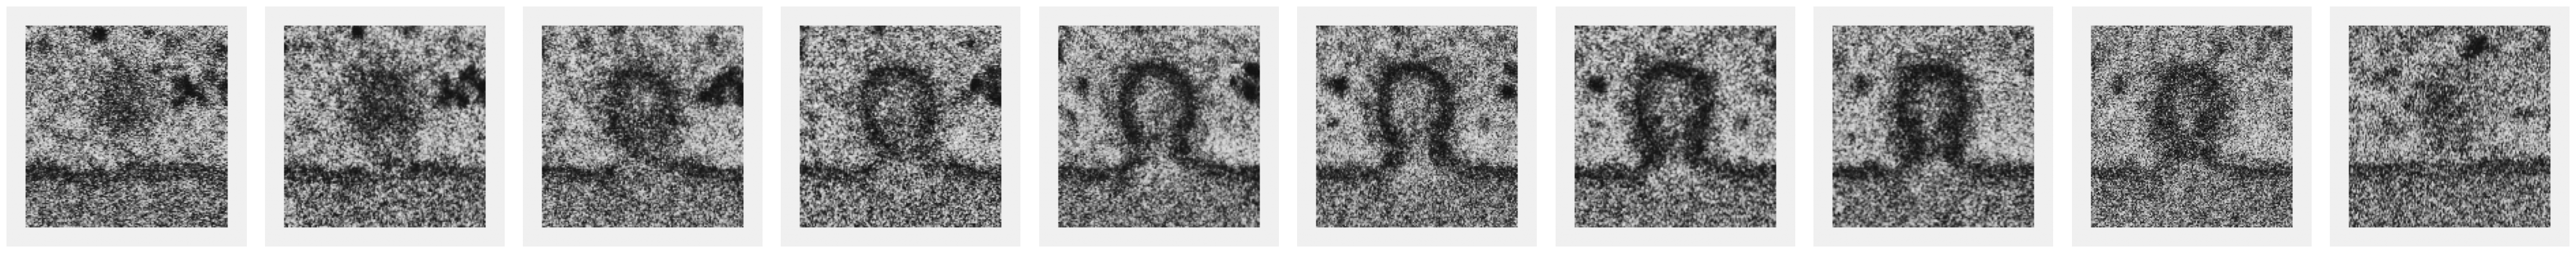

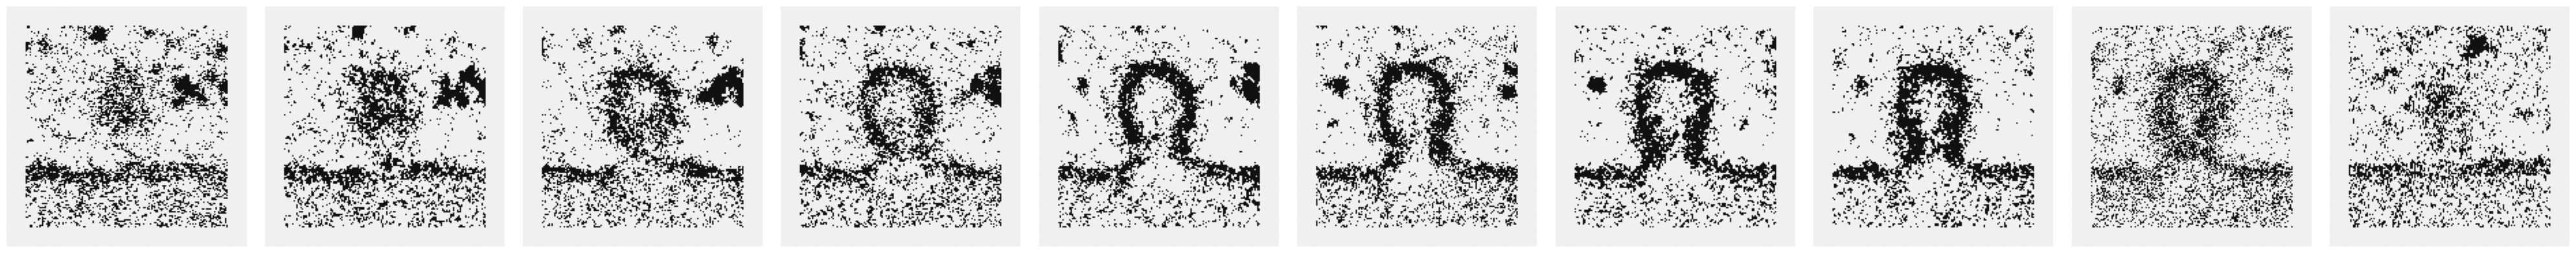

In [111]:
from data_generation.preprocess import overlay_points_on_cryoet

#### Parameters ####
threshold = 0.7
# threshold = None
n_slices = 8
slices = list(range(60, 110, 5))

# visualize = cryoet
# visualize = cryoet_resized
# visualize = clahe_vol
visualize = test

#### Visualize Data ####
# plot_multiple_slices(visualize, axis='z', num_slices=n_slices, thre=threshold)
# plot_multiple_slices(visualize, axis='y', num_slices=n_slices, thre=threshold)
# plot_multiple_slices(visualize, axis='x', num_slices=n_slices, thre=threshold)

overlay_points_on_cryoet(cryoet=visualize, axis='x', slice_index=slices)
overlay_points_on_cryoet(cryoet=visualize, axis='x', slice_index=slices, threshold=threshold)

#### Save Reformatted Data ####
save_path = f"../data/experimental/vol/formatted/{data_id}/{shape}.tif"
tiff.imwrite(save_path, 1-clahe_vol)

In [17]:
from data_generation.preprocess import downsample_binary_mask_to_fraction

in_min   = 0
in_max   = 0.01
out_min  = 0.24
out_max  = 0.27
edge_min = 0.8
edge_max = 1.0
target_edge = 1.
target_bulk = 0.05
target_out  = 0.
target_in   = 0.

slice_min   = 134
slice_max   = 164

Z = clahe_vol.shape[0]
z = np.arange(Z)[:, None, None]   # shape (Z,1,1)

# edge    = (clahe_vol >= edge_min) & (clahe_vol <= edge_max)
edge = filtered
# edge = cleaned
# edge = clahe_vol
bulk    = (~edge)
mask_remove = ((z >= 154) & (z <= 164)) | ((z >= 320) & (z <= 330))
bulk = bulk & (~mask_remove)
# bulk = (~edge) & (z >= slice_min) & (z <= slice_max)
# outside = (normalized >= out_min)  & (normalized <= out_max)
# inside  = (normalized >= in_min)   & (normalized <= in_max)

outside = (clahe_vol >= out_min)  & (clahe_vol <= out_max)
inside  = (clahe_vol >= in_min)   & (clahe_vol <= in_max)


edge    = downsample_binary_mask_to_fraction(edge,    target_frac=target_edge, seed=0)
bulk    = downsample_binary_mask_to_fraction(bulk,    target_frac=target_bulk, seed=0)
outside = downsample_binary_mask_to_fraction(outside, target_frac=target_out, seed=0)
inside  = downsample_binary_mask_to_fraction(inside , target_frac=target_in, seed=0)

# outside = outside & (~edge)
# inside = inside & (~edge)

edge = edge.astype(np.float32)
bulk = bulk.astype(np.float32)
outside = outside.astype(np.float32)
inside = inside.astype(np.float32)

print("edge: ",    edge.sum())
print("bulk: ",    bulk.sum())
print("outside: ", outside.sum())
print("inside: ",  inside.sum())

edge:  113736.0
bulk:  162090.0
outside:  0.0
inside:  0.0


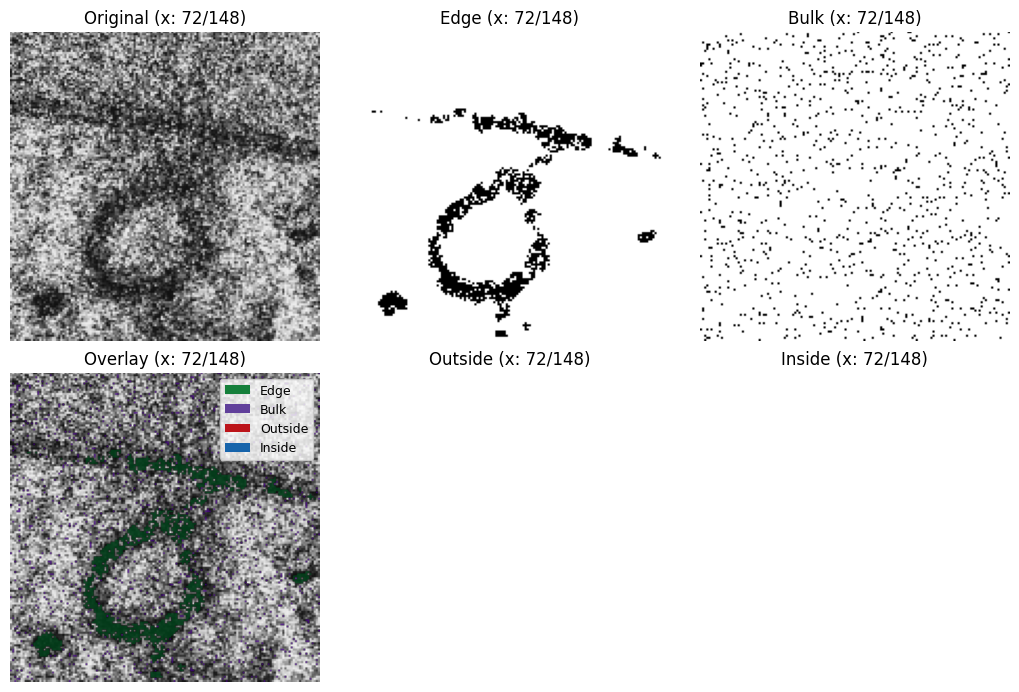

In [18]:
# Visualize data
from data_generation.preprocess import plot_edge_and_region, overlay_masks_on_cryoet, plot_edge_region_with_bulk_2rows

axis = "x"
slice_index = 72
# slice_index = 170

# plot_edge_and_region(normalized, edge, outside, inside, axis=axis, slice_index=slice_index)
# overlay_masks_on_cryoet(normalized, edge, outside, inside, axis=axis, slice_index=slice_index, alpha=0.8)

plot_edge_region_with_bulk_2rows(clahe_vol, edge, bulk, outside, inside, axis=axis, slice_index=slice_index, alpha=0.8)

In [155]:
## To reload

import importlib
import data_generation.preprocess as preprocess

importlib.reload(preprocess)

<module 'data_generation.preprocess' from '/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/src/data_generation/preprocess.py'>

In [19]:
## Reformat and save data

from data_generation.preprocess import build_data_sign_from_masks, build_data_edge_from_masks
import mrcfile

data_sign = build_data_sign_from_masks(
    outside=outside,
    inside=inside,
    # volume_shape=normalized.shape,
    volume_shape=cryoet.shape,
)

data_edge = build_data_edge_from_masks(
    edge=edge,
    bulk=bulk,
    volume_shape=normalized.shape,
    # volume_shape=cryoet.shape,
)

# print("data_sign count: ", data_sign["sign"].shape)
print("data_edge count: ", data_edge["label"].shape)

# save_file = f"../data/experimental/sign/{shape}.npz"
# np.savez(
#     save_file,
#     points=np.asarray(data_sign["points"]),
#     sign=np.asarray(data_sign["sign"]),
# )

# save_file = f"../data/experimental/edge/{shape}.npz"
save_file = f"../data/experimental/edge/jrc_cos7-1b/{shape}.npz"
np.savez(
    save_file,
    points=np.asarray(data_edge["points"]),
    label=np.asarray(data_edge["label"]),
)

edge_mrc = f"../data/experimental/masked/{shape}.mrc"
with mrcfile.new(edge_mrc, overwrite=True) as mrc:
    mrc.set_data(edge.astype(np.float32))

data_edge count:  (275826,)


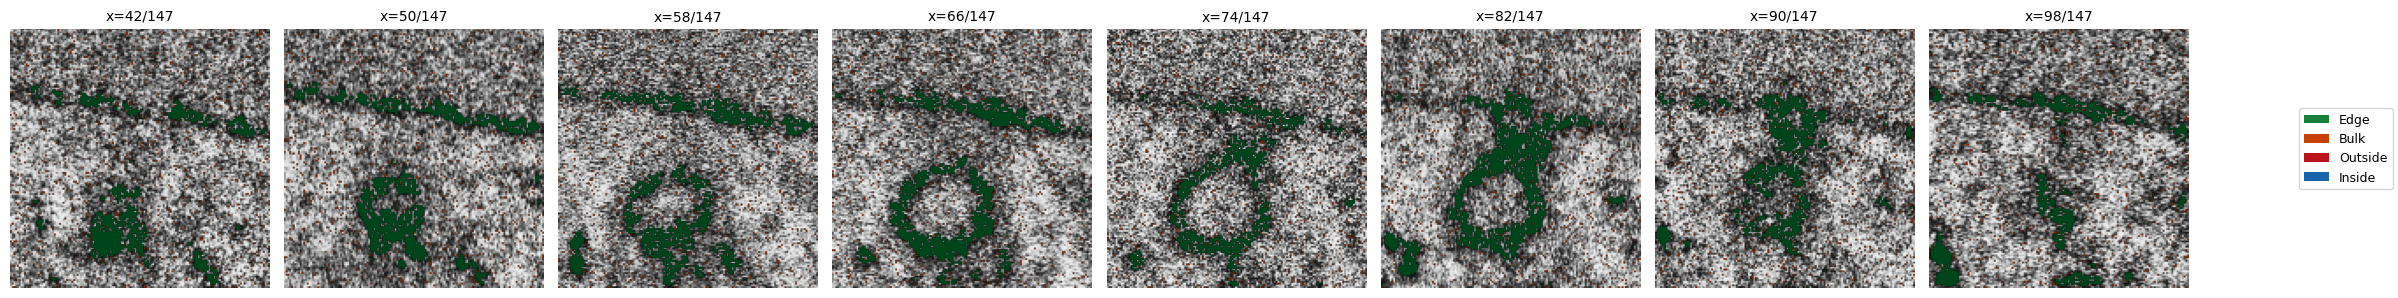

In [54]:
from data_generation.preprocess import overlay_masks_on_cryoet_slices

# slice_index = [110, 111]
# slice_index = np.arange(10, 208, 25)
# slice_index = np.arange(1, 360, 50)
slice_index = np.arange(42, 105, 8)
# slice_index = [50, 60, 70, 80, 90]
# slice_index = [65, 67, 70, 73, 75]
axis = "x"

overlay_masks_on_cryoet_slices(
    cryoet=clahe_vol,
    edge=edge,
    bulk=bulk,
    outside=outside,
    inside=inside,
    axis=axis,
    slice_indices=slice_index,
    alpha=1,
)


In [14]:
import mrcfile
shape = "bud-1"
mrc_path = f"../data/experimental/downsampled/jrc_cos7-1b/{shape}.mrc"
with mrcfile.new(mrc_path, overwrite=True) as mrc:
    # mrc.set_data(normalized.astype(np.float32))
    mrc.set_data(clahe_vol.astype(np.float32))

In [55]:
import mrcfile
import numpy as np
output_file = f"../data/experimental/sam3/mrc/{shape}.mrc"
with mrcfile.new(output_file, overwrite=True) as mrc:
    # mrc.set_data(normalized.astype(np.float32))
    mrc.set_data(clahe_vol.astype(np.float32))

In [ ]:
## Visualize sampled points
from pinn.utils import visualize_sign_sampling_mrc

GRID_SIZE = 128
shape = "mend_1"
# save_sign_dir = f"../outputs/logs/{shape}/manual_signs.npz"
save_sign_dir = f"../data/experimental/sign/{shape}.npz"
# save_sign_dir = f"../outputs/logs/mito_1/manual_signs_inm.npz"
# mrc_file_path = f"../data/experimental/downsampled/{shape}.mrc"
mrc_file_path = f"../data/experimental/masked/{shape}.mrc"
cryoET_data = load_mrc_data(mrc_file_path, grid_size=GRID_SIZE)
checkpoint_data = cryoET_data

signs = load_sign_data(save_sign_dir, perm=(0,1,2))
out = visualize_sign_sampling_mrc(grid_size=GRID_SIZE, slice_index=GRID_SIZE//2, cryoET_data=cryoET_data, signs=signs, slice_thickness_vox=0)

# signs

In [182]:
### PHYSICS POINTS SAMPLING ###

from pinn.utils import sample_collocation_points, save_pts_data
import jax

num_collocation = 80000  #20000
seed = 0
key = jax.random.PRNGKey(seed)

## ===== COLLOCATION POINTS SAMPLING ========
x_train = (jax.random.uniform(key, (num_collocation, 3), minval=-1, maxval=1))
data_phys = {"points": x_train}

## ===== STORE META DATA ========
meta_phys = {
    "type": "phys",
    "n_sample": num_collocation,
    "seed": seed,
    "sampling": "uniform",
}
print("physics: ", data_phys["points"].shape[0])

save_data_dir = f"../data/experimental/phys"
save_pts_data(data_phys, f"{save_data_dir}/p_uniform_{num_collocation}.npz", meta_phys)

physics:  80000


(<Figure size 2000x400 with 5 Axes>,
 array([<Axes: title={'center': 'z=59'}>, <Axes: title={'center': 'z=66'}>,
        <Axes: title={'center': 'z=73'}>, <Axes: title={'center': 'z=79'}>,
        <Axes: title={'center': 'z=85'}>], dtype=object))

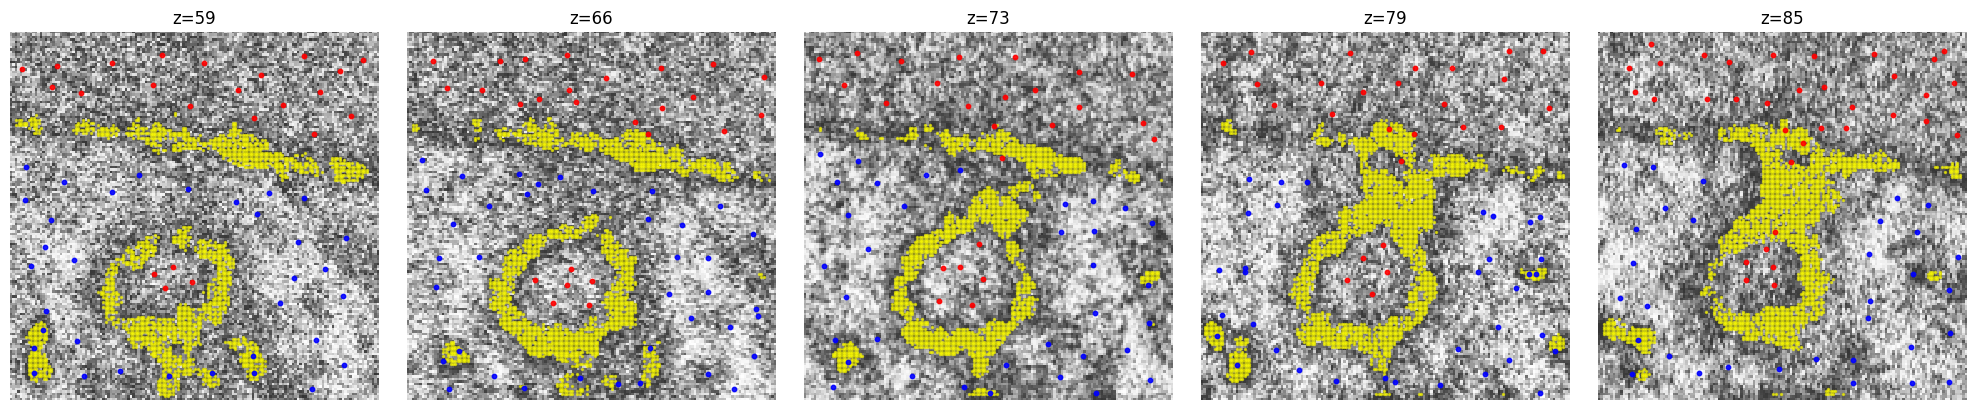

In [25]:
### IMPORT SAMPLING POINTS AND PLOT ###
from data_generation.preprocess import overlay_cryoet_with_points
from pinn.utils import load_pts_data
import mrcfile


### PARAMETERS ###
shape = "bud-1"
# slice_index = [50, 60, 70, 80, 90]
# slice_index = [12, 39, 55, 90, 109, 132, 149, 173, 214, 256, 285, 312, 338, 347] # for mend_3
# slice_index = [12, 39, 55, 90, 109, 132]
# slice_index = np.arange(1, 360, 50)
# slice_index = [45,55,66,76,83] # for czii_gl_1
# slice_index = list(range(40, 80, 4))
slice_index = np.arange(42, 105, 8)
slice_index = [59,66,73,79,85]
axis = 'z'

### IMPORT MRC FILE ###
my_data_path = "../data/experimental/downsampled/jrc_cos7-1b"
# my_data_path = "../data/experimental/sam3/mrc"
file_path = f"{my_data_path}/{shape}.mrc"
with mrcfile.open(file_path, permissive=True) as mrc:
    cryoet = mrc.data

### IMPORT EDGE SIGNAL ###
pts_path = f"../data/experimental"
edge = load_pts_data(f"{pts_path}/edge/jrc_cos7-1b/{shape}.npz", perm=(0,1,2))
# sign = load_pts_data(f"{pts_path}/sign/{shape}/manual_signs.npz", perm=(0,1,2))
sign = load_pts_data(f"{pts_path}/sign/jrc_cos7-1b/{shape}.npz", perm=(0,1,2))

### PLOT ###
overlay_cryoet_with_points(
    cryoet=cryoet,
    edge=edge,
    sign=sign,
    axis=axis,
    slice_indices=slice_index,
    # alpha=1,
)

In [29]:
## To reload

import importlib
import data_generation.preprocess as preprocess
importlib.reload(preprocess)

<module 'data_generation.preprocess' from '/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/src/data_generation/preprocess.py'>